# Quickstart: Surface Albedo

In this notebook, we'll run our first pyRadtran simulation — computing broadband irradiance for a range of surface albedo values. This demonstrates the basic workflow: create an input dataset, configure the simulation, run it, and visualize the results.

## What We'll Learn

- How to build a basic simulation configuration
- How to create an input xarray `Dataset` with varying parameters
- How to run a simulation and inspect the results
- How to produce quick visualizations with xarray and matplotlib

This is a minimal configuration — just enough to run a simulation. We'll build on this in later notebooks.

In [1]:
import pyradtran  # Registers the .pyradtran xarray accessor
from pyradtran import Var
from pyradtran import load_config
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
import logging

# Suppress verbose solver output (change to DEBUG to see details)
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

# ── Simulation parameters ─────────────────────────────────────────────────────
# Start from merged defaults + master config (~/.pyradtran/config.yaml)
cfg = load_config()

# Spectral range and solver
cfg.simulation_defaults.wavelength_nm        = [400, 700]   # broadband visible
cfg.simulation_defaults.rte_solver           = "disort"
cfg.simulation_defaults.mol_abs_param        = "lowtran per_nm"
cfg.simulation_defaults.source               = "solar"
cfg.simulation_defaults.integrate_wavelength = True

# Output
cfg.simulation_defaults.output_altitudes_km  = [0.0]
cfg.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]

# Execution
cfg.execution.max_workers        = 1
cfg.execution.cleanup_temp_files = False

# Save so the run is reproducible
config_path = Path("config/albedo.yaml")
cfg.to_yaml(config_path)
print(f"Config saved to {config_path}")

# ── Input dataset ─────────────────────────────────────────────────────────────
# Single time step at Leipzig, Germany
# 100 altitude levels from 0 to 99 km
# 20 different albedo values as a sweep dimension
N_albedo = 20
albedo_values = np.linspace(0.1, 0.9, N_albedo)

ds = xr.Dataset(
    coords={
        'time': [pd.to_datetime('2025-04-04T08:00:00')],
        'latitude': ('time', [51.34]),
        'longitude': ('time', [12.37]),
        'altitude': ('altitude', np.arange(0, 100, 1)),
    },
    data_vars={
        'albedo': ('albedo_dim', albedo_values),
    }
)

# ── Run ───────────────────────────────────────────────────────────────────────
ds_sim = ds.pyradtran.run(
    config_path=config_path,
    params={'albedo': Var('albedo')},  # Map the 'albedo' variable to the libRadtran albedo parameter
    show_progress=False,
)

print("Simulation complete!")
print(f"Variables: {list(ds_sim.data_vars.keys())}")
print(f"Dimensions: {dict(ds_sim.dims)}")

2026-04-19 01:24:25,025 - pyradtran.config - INFO - Configuration written to config/albedo.yaml


Config saved to config/albedo.yaml
Simulation complete!
Variables: ['zout', 'lambda', 'sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Dimensions: {'albedo_dim': 20, 'time': 1, 'altitude': 100}


/tmp/ipykernel_16765/3823483834.py:65: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds_sim.dims)}")


## Results: Altitude Profiles

Let's visualize how the upwelling irradiance varies with altitude for different albedo values:

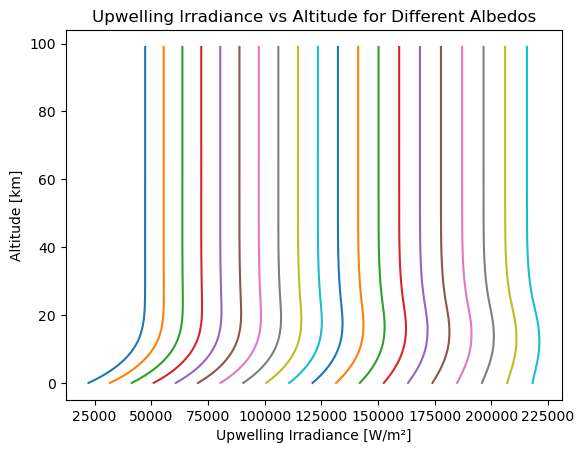

In [2]:
ds_sim.eup.squeeze().plot(hue='albedo_dim', y='altitude', add_legend=False)
plt.xlabel('Upwelling Irradiance [W/m²]')
plt.ylabel('Altitude [km]')
plt.title('Upwelling Irradiance vs Altitude for Different Albedos')
plt.show()

## Results: Albedo Dependence

Now let's look at how the surface-level upwelling irradiance depends on albedo. As expected, higher surface albedo leads to more reflected (upwelling) radiation:

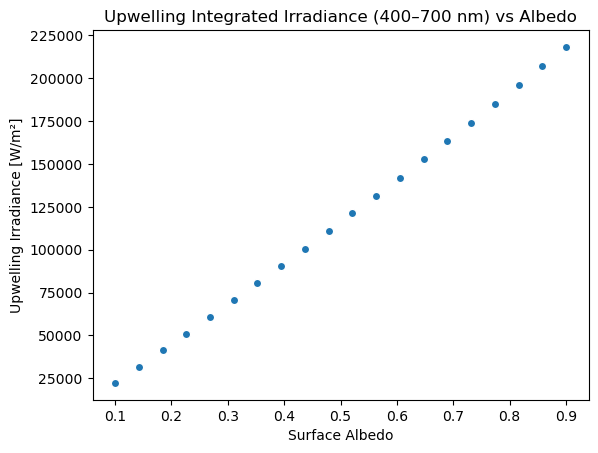

In [3]:
ds_sim.sel(altitude=0).plot.scatter(x='albedo', y='eup')
plt.title('Upwelling Integrated Irradiance (400–700 nm) vs Albedo')
plt.xlabel('Surface Albedo')
plt.ylabel('Upwelling Irradiance [W/m²]')
plt.show()